In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load cleaned stock prices dataset
df = pd.read_csv("cleaned_stock_prices.csv")

# Display first 5 rows
df.head()

,symbol,date,open,high,low,close,volume
0,A,2014-01-02,57.10,57.100,56.15,56.21,1916160
1,A,2014-01-03,56.39,57.345,56.26,56.92,1866651
2,A,2014-01-06,57.40,57.700,56.56,56.64,1777472
3,A,2014-01-07,56.95,57.630,56.93,57.45,1463208
4,A,2014-01-08,57.33,58.540,57.17,58.39,2659468


In [5]:
# Check dataset information
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497472 non-null  float64
 3   high    497472 non-null  float64
 4   low     497472 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 26.6 MB


symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [6]:
# Independent variable: open price
X = df[["open"]]

# Dependent variable: close price
y = df["close"]

In [7]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (397977, 1)
Testing data: (99495, 1)


In [8]:
# Create the linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
# Predict closing prices using the test data
y_pred = model.predict(X_test)

# Display first 10 predictions
y_pred[:10]

array([ 98.99641315,  53.01278   ,  85.10833608,  72.3051088 ,
        35.18524838,  91.7874113 ,  65.1910938 ,  46.29371031,
        58.4620255 , 122.96309475])

In [10]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 2.555011071496872
R-squared: 0.9997433604058968


In [11]:
# Get model coefficient and intercept
coefficient = model.coef_[0]
intercept = model.intercept_

print("Coefficient:", coefficient)
print("Intercept:", intercept)

Coefficient: 0.9998615602008403
Intercept: 0.030115920904819404


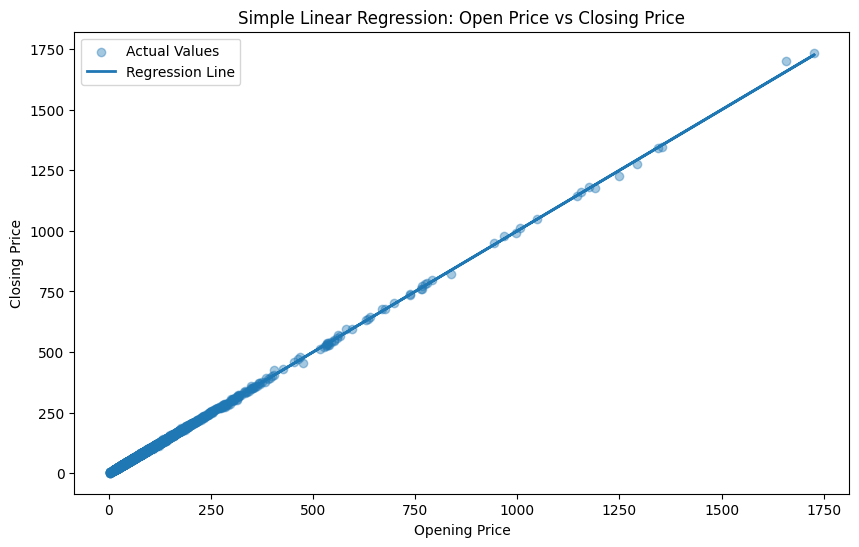

In [12]:
# Create a sample for clearer visualization
sample_df = df.sample(n=5000, random_state=42)

X_sample = sample_df[["open"]]
y_sample = sample_df["close"]
y_sample_pred = model.predict(X_sample)

plt.figure(figsize=(10, 6))

plt.scatter(X_sample["open"], y_sample, alpha=0.4, label="Actual Values")
plt.plot(X_sample["open"], y_sample_pred, linewidth=2, label="Regression Line")

plt.title("Simple Linear Regression: Open Price vs Closing Price")
plt.xlabel("Opening Price")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

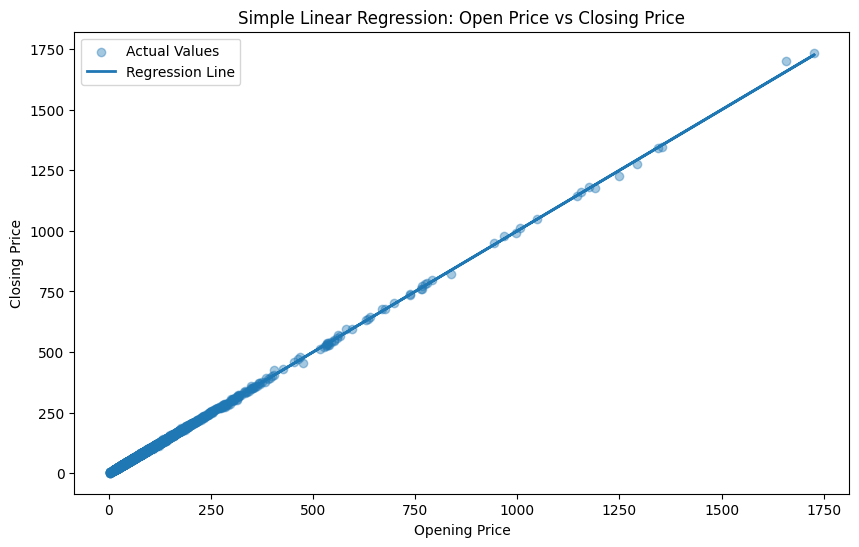

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(X_sample["open"], y_sample, alpha=0.4, label="Actual Values")
plt.plot(X_sample["open"], y_sample_pred, linewidth=2, label="Regression Line")

plt.title("Simple Linear Regression: Open Price vs Closing Price")
plt.xlabel("Opening Price")
plt.ylabel("Closing Price")
plt.legend()

plt.savefig("simple_linear_regression_open_vs_close.png", bbox_inches="tight")
plt.show()

## Level 2 Task 1: Regression Analysis Summary

For this task, I performed a simple linear regression analysis using the cleaned stock prices dataset. The objective was to predict the closing stock price using the opening stock price.

The independent variable was `open`, and the dependent variable was `close`. The dataset was split into training and testing sets using an 80/20 split. A Linear Regression model from scikit-learn was trained on the training data and tested on unseen testing data.

The model was evaluated using Mean Squared Error and R-squared. Mean Squared Error measured the size of the prediction errors, while R-squared measured how well the opening price explained the variation in the closing price.

The coefficient showed how much the predicted closing price changed when the opening price increased by one unit. Since opening and closing prices are strongly related, the model was expected to produce a high R-squared value.

A scatter plot with a regression line was created to visualize the relationship between opening price and closing price. The visualization showed a strong positive relationship, meaning that stocks with higher opening prices generally also had higher closing prices.